In [1]:
import os
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:


base_path_1 = "C:/Users/dacnu/OneDrive/Desktop/AI stuff/TEM virus dataset"

print(os.listdir(base_path_1))

['context_virus_1nm_256x256', 'context_virus_RAW', 'filtered_virus_dataset']


In [3]:


base_path_2 = "C:/Users/dacnu/OneDrive/Desktop/AI stuff/TEM virus dataset/context_virus_RAW"

for split in ["train", "validation", "test"]:
    split_path = os.path.join(base_path_2, split)
    print(f"\n{split}:")
    print(os.listdir(split_path))


train:
['Adenovirus', 'Astrovirus', 'CCHF', 'Cowpox', 'Dengue', 'Ebola', 'Guanarito', 'Influenza', 'Lassa', 'LCM', 'Machupo', 'Marburg', 'Nipah virus', 'Norovirus', 'Orf', 'Papilloma', 'Pseudocowpox', 'Rift Valley', 'Rotavirus', 'Sapovirus', 'TBE', 'WestNile']

validation:
['Adenovirus', 'Astrovirus', 'CCHF', 'Cowpox', 'Dengue', 'Ebola', 'Guanarito', 'Influenza', 'Lassa', 'LCM', 'Machupo', 'Marburg', 'Nipah virus', 'Norovirus', 'Orf', 'Papilloma', 'Pseudocowpox', 'Rift Valley', 'Rotavirus', 'Sapovirus', 'TBE', 'WestNile']

test:
['Adenovirus', 'Astrovirus', 'CCHF', 'Cowpox', 'Dengue', 'Ebola', 'Guanarito', 'Influenza', 'Lassa', 'LCM', 'Machupo', 'Marburg', 'Nipah virus', 'Norovirus', 'Orf', 'Papilloma', 'Pseudocowpox', 'Rift Valley', 'Rotavirus', 'Sapovirus', 'TBE', 'WestNile']


In [4]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

base_path = "C:/Users/dacnu/OneDrive/Desktop/AI stuff/TEM virus dataset/filtered_virus_dataset"

train_data = datasets.ImageFolder(base_path + "/train", transform=train_transform)
val_data   = datasets.ImageFolder(base_path + "/validation", transform=test_transform)
test_data  = datasets.ImageFolder(base_path + "/test", transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

print("Classes:", train_data.classes)
print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Classes: ['Adenovirus', 'Cowpox', 'Influenza']
Train batches: 4
Val batches: 2
Test batches: 2


In [5]:
import torch.nn as nn
import torch.nn.functional as F

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)

        self.adaptive_pool = nn.AdaptiveAvgPool2d((7, 7))

        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 3)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

model = SimpleCNN()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [7]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [8]:
best_val_acc = 0.0

for epoch in range(25):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    val_acc = evaluate(model, test_loader)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_virus_classifier.pth")

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}, Val Acc: {val_acc:.4f}")

print(f"Best validation accuracy: {best_val_acc:.4f}")

Epoch 1, Loss: 1.0784, Val Acc: 0.4419
Epoch 2, Loss: 1.0221, Val Acc: 0.7442
Epoch 3, Loss: 0.9564, Val Acc: 0.7442
Epoch 4, Loss: 0.8808, Val Acc: 0.7442
Epoch 5, Loss: 0.7900, Val Acc: 0.7442
Epoch 6, Loss: 0.7610, Val Acc: 0.7442
Epoch 7, Loss: 0.7432, Val Acc: 0.7442
Epoch 8, Loss: 0.7456, Val Acc: 0.7442
Epoch 9, Loss: 0.6925, Val Acc: 0.7442
Epoch 10, Loss: 0.6945, Val Acc: 0.7442
Epoch 11, Loss: 0.6663, Val Acc: 0.7907
Epoch 12, Loss: 0.6466, Val Acc: 0.8140
Epoch 13, Loss: 0.5978, Val Acc: 0.8140
Epoch 14, Loss: 0.5788, Val Acc: 0.8605
Epoch 15, Loss: 0.5422, Val Acc: 0.8605
Epoch 16, Loss: 0.5203, Val Acc: 0.8372
Epoch 17, Loss: 0.5202, Val Acc: 0.8372
Epoch 18, Loss: 0.5066, Val Acc: 0.8605
Epoch 19, Loss: 0.4871, Val Acc: 0.8605
Epoch 20, Loss: 0.4828, Val Acc: 0.8605
Epoch 21, Loss: 0.4348, Val Acc: 0.8605
Epoch 22, Loss: 0.4241, Val Acc: 0.8605
Epoch 23, Loss: 0.4332, Val Acc: 0.8605
Epoch 24, Loss: 0.3965, Val Acc: 0.9070
Epoch 25, Loss: 0.4007, Val Acc: 0.8837
Best vali

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [10]:
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()
accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 88.37%


In [11]:
def predict_virus(image_path, model, transform, class_names):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)
        confidence, predicted_idx = torch.max(probabilities, 1)

    predicted_class = class_names[predicted_idx.item()]
    confidence = confidence.item()

    return predicted_class, confidence

In [12]:
import pandas as pd

# ---------- Adenovirus ----------
adeno = pd.read_csv("adenovirus_pdb_antibody_sequences.csv")

adeno_clean_rows = []

for pdb_id, group in adeno.groupby("PDB_ID"):
    heavy = group[group["Chain_Type_Guess"] == "heavy"]
    light = group[group["Chain_Type_Guess"] == "light"]

    if len(heavy) > 0 and len(light) > 0:
        adeno_clean_rows.append({
            "Virus": "Adenovirus",
            "Source_ID": pdb_id,
            "VH_sequence": heavy.iloc[0]["Sequence"],
            "VL_sequence": light.iloc[0]["Sequence"],
            "Title": group.iloc[0]["Title"]
        })

adeno_clean = pd.DataFrame(adeno_clean_rows)

print("Adenovirus cleaned:", adeno_clean.shape)
adeno_clean.head()

Adenovirus cleaned: (71, 5)


,Virus,Source_ID,VH_sequence,VL_sequence,Title
0,Adenovirus,11OU,QVQLVESGGGVVQPGRSLRLSCAASGFTFSSYGMHWVRQAPGKGLE...,EVQLQESGGGLVQPGGSLRLSCAASGRTISRYAMSWFRQAPGKERE...,Omi32 germline Fab in complex with LC-Kappa VHH
1,Adenovirus,15C8,EVQLQQSGAELVKPGASVKLSCTASGFNIKDTYMHWVKQKPEQGLE...,DIVLTQSPAIMSASLGERVTMTCTASSSVSSSNLHWYQQKPGSSPK...,"CATALYTIC ANTIBODY 5C8, FREE FAB"
2,Adenovirus,1A5F,EVALQQSGAELVKPGASVKLSCAASGFTIKDAYMHWVKQKPEQGLE...,DIVMTQSPSSLTVTTGEKVTMTCKSSQSLLNSGAQKNYLTWYQQKP...,FAB FRAGMENT OF A MONOCLONAL ANTI-E-SELECTIN A...
3,Adenovirus,1AJ7,QVQLQQSGAELVKPGASVKLSCTASGFNIKDTYMHWVKQRPEQGLE...,DIQMTQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,IMMUNOGLOBULIN 48G7 GERMLINE FAB ANTIBODY COMP...
4,Adenovirus,1BZ7,DVQLVESGGGLVQPGGSRKLSCAASGFTFSNFGMHWVRQAPEKGLE...,DIQMTQITSSLSVSLGDRVIISCRASQDIGNFLNWYQQKPDGSLKL...,FAB FRAGMENT FROM MURINE ASCITES


In [13]:
# ---------- Influenza ----------
flu_raw = pd.read_excel("Influenza_data.xlsx", sheet_name="Sheet1")

# Drop the first row because it is a header-description row, not real data
flu = flu_raw.iloc[1:].copy()

flu_clean = pd.DataFrame({
    "Virus": "Influenza",
    "Source_ID": flu["Receptor"],
    "VH_sequence": flu["Chain 1.30"],
    "VL_sequence": flu["Chain 2.30"],
    "Title": flu["Epitope"]
})

flu_clean = flu_clean.dropna(subset=["VH_sequence", "VL_sequence"])

print("Influenza cleaned:", flu_clean.shape)
flu_clean.head()

Influenza cleaned: (206, 5)


,Virus,Source_ID,VH_sequence,VL_sequence,Title
1,Influenza,https://www.iedb.org/receptor/113,EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGPE...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPK...,https://www.iedb.org/epitope/226309
2,Influenza,https://www.iedb.org/receptor/113,EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGPE...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPK...,https://www.iedb.org/epitope/2224248
3,Influenza,https://www.iedb.org/receptor/113,EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGPE...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPK...,https://www.iedb.org/epitope/2224248
4,Influenza,https://www.iedb.org/receptor/113,EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGPE...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPK...,https://www.iedb.org/epitope/2224247
5,Influenza,https://www.iedb.org/receptor/113,EVQLVESGAEVKKPGSSVKVSCKASGGPFRSYAISWVRQAPGQGPE...,QSVLTQPPSVSAAPGQKVTISCSGSSSNIGNDYVSWYQQLPGTAPK...,https://www.iedb.org/epitope/2224248


In [14]:
import pandas as pd

bind_col = "Binds to(virus[-clade]_strain_location_protein)"

pox = pd.read_csv("Pox-AbDab_09012026.csv")

pox_clean = pd.DataFrame({
    "Virus": "Cowpox",
    "Source_ID": pox["Name"],
    "VH_sequence": pox["VH or VHH"],
    "VL_sequence": pox["VL"],
    "Title": pox[bind_col]
})

pox_clean = pox_clean.dropna(subset=["VH_sequence", "VL_sequence"])

pox_clean = pox_clean[
    pox_clean["Title"].astype(str).str.contains(
        "CPXV|VACV|MPXV|VARV",
        case=False,
        na=False
    )
]

print("Pox cleaned:", pox_clean.shape)
pox_clean.head()

Pox cleaned: (145, 5)


,Virus,Source_ID,VH_sequence,VL_sequence,Title
1,Cowpox,12C-paper,EVQLESSGAEVKKPGASVKVSCKASGYTFTKYTIHWVRQAPGQRLE...,ELVLTQPPSVSVYPGQTASITCSGDKLGDKYVSWYQQKSAQPPVLV...,VACV_?_EEV_A33(r)
2,Cowpox,12C-patent,EVQLESSGAEVKKPGASVKVSCKASGYTFTKYTIHWVRQAPGQRLE...,ELVLTQPPSVSVYPGQTASITCSGDKLGDKYVSWYQQKSAQPPVLV...,VACV_?_EEV_A33(r)
4,Cowpox,12F-paper,EVQLESSGAEVKKPGASVKVSCKASGYTFASYWIVWVRQMPGKGLE...,ELALTQPASVSGSPGQSITISCTGTSSDVGGYNAVSWYQQHPGKAP...,VACV_?_EEV_A33(r)
5,Cowpox,12F-patent,EVQLESSGAEVKKPGESLKISCKGSGYTFASYWIVWVRQMPGKGLE...,ELALTQPASVSGSPGQSITISCTGTSSDVGGYNAVSWYQQHPGKAP...,VACV_?_EEV_A33(r)
7,Cowpox,1G6,QVTLKESGPGILKPSQTLSLTCSFSGFSLSTSGMGVGWIRQPSGKG...,DVVMTQTPLSLSVSLGDQASISCRSSQSLVHSNGNTYLHWYLQKPG...,VACV_?_MV_A27(r)


In [15]:
combined_antibodies = pd.concat(
    [adeno_clean, flu_clean, pox_clean],
    ignore_index=True
)

combined_antibodies["target_text"] = (
    "<VH> " + combined_antibodies["VH_sequence"].astype(str) +
    " <VL> " + combined_antibodies["VL_sequence"].astype(str) +
    " <END>"
)

combined_antibodies.to_csv("FINAL_antibody_dataset.csv", index=False)

print("Final dataset:", combined_antibodies.shape)
combined_antibodies["Virus"].value_counts()

Final dataset: (422, 6)


Virus
Influenza     206
Cowpox        145
Adenovirus     71
Name: count, dtype: int64

In [16]:
def retrieve_antibodies(predicted_class, antibody_df, n=5):
    matches = antibody_df[antibody_df["Virus"] == predicted_class]

    if len(matches) == 0:
        return f"No antibody sequences found for {predicted_class}"

    return matches.sample(min(n, len(matches)), random_state=42)[
        ["Virus", "Source_ID", "VH_sequence", "VL_sequence", "Title"]
    ]

In [17]:
def retrieve_best_antibodies(predicted_class, antibody_df, n=5):
    matches = antibody_df[antibody_df["Virus"] == predicted_class].copy()

    if len(matches) == 0:
        return f"No antibody sequences found for {predicted_class}"

    # Prefer rows with longer/non-empty VH and VL sequences
    matches["VH_length"] = matches["VH_sequence"].astype(str).str.len()
    matches["VL_length"] = matches["VL_sequence"].astype(str).str.len()
    matches["sequence_score"] = matches["VH_length"] + matches["VL_length"]

    # Prefer rows with more informative titles
    matches["title_score"] = matches["Title"].astype(str).str.len()

    matches["rank_score"] = matches["sequence_score"] + matches["title_score"]

    return matches.sort_values("rank_score", ascending=False).head(n)[
        ["Virus", "Source_ID", "Title", "VH_sequence", "VL_sequence", "rank_score"]
    ]

In [18]:
# Example: after predicting an image
class_names = train_data.classes
test_image_path = test_data.samples[0][0]

predicted_class, confidence = predict_virus(
    test_image_path,
    model,
    test_transform,
    class_names
)

print("Image:", test_image_path)
print("Predicted virus:", predicted_class)
print("Confidence:", confidence)

retrieve_best_antibodies(predicted_class, combined_antibodies, n=5)

Image: C:/Users/dacnu/OneDrive/Desktop/AI stuff/TEM virus dataset/filtered_virus_dataset/test\Adenovirus\A4-080201_13.tif
Predicted virus: Adenovirus
Confidence: 0.7572277188301086


,Virus,Source_ID,Title,VH_sequence,VL_sequence,rank_score
15,Adenovirus,3PP3,Epitope characterization and crystal structure...,QVQLVQSGAEVKKPGSSVKVSCKASGYAFSYSWINWVRQAPGQGLE...,DIVMTQTPLSLPVTPGEPASISCRSSKSLLHSNGITYLYWYLQKPG...,602
3,Adenovirus,1AJ7,IMMUNOGLOBULIN 48G7 GERMLINE FAB ANTIBODY COMP...,QVQLQQSGAELVKPGASVKLSCTASGFNIKDTYMHWVKQRPEQGLE...,DIQMTQSPSSLSASLGERVSLTCRASQEISGYLSWLQQKPDGTIKR...,590
13,Adenovirus,3O2V,Crystal structure of 1E9 PheL89Ser/LeuH47Trp/M...,QVQLVQSGPELKKPGETVKISCKASGYMFTNYGMNWVKQAPGKALK...,ELVMTQTPLSLPVSLGDQASISCRSSQSLVHSNGNTYLHWYLQKPG...,585
8,Adenovirus,2A6D,Crystal structure analysis of the anti-arsonat...,EVQLQQSGAELVRAGSSVKMSCKASGYTFTSYGINWVKQRPGQGLE...,DIQMTQTTSSLSASLGDRVTISCRASQDISNYLNWYQQKPDGTVKL...,574
43,Adenovirus,6QNK,Antibody FAB fragment targeting Gi protein het...,MDSRLNLVFLVLTLKGVQCDVQLVESGGGLVQPGGSRKLSCSASGF...,MRCLAEFLGLLVLWIPGAIGDIVMTQATSSVPVTPGESVSISCRSS...,566


In [19]:
import random
from collections import defaultdict, Counter

def build_markov_model(sequences, k=3):
    model = defaultdict(Counter)

    for seq in sequences:
        seq = str(seq).replace(" ", "").upper()
        seq = "^" * k + seq + "$"

        for i in range(len(seq) - k):
            context = seq[i:i+k]
            next_char = seq[i+k]
            model[context][next_char] += 1

    return model

def generate_sequence(model, k=3, max_len=140):
    context = "^" * k
    output = ""

    for _ in range(max_len):
        choices = model.get(context)

        if not choices:
            break

        chars = list(choices.keys())
        weights = list(choices.values())

        next_char = random.choices(chars, weights=weights)[0]

        if next_char == "$":
            break

        output += next_char
        context = context[1:] + next_char

    return output

In [20]:
generators = {}

for virus in combined_antibodies["Virus"].unique():
    subset = combined_antibodies[combined_antibodies["Virus"] == virus]

    vh_model = build_markov_model(subset["VH_sequence"], k=3)
    vl_model = build_markov_model(subset["VL_sequence"], k=3)

    generators[virus] = {
        "VH": vh_model,
        "VL": vl_model
    }

print("Generators built for:", generators.keys())

Generators built for: dict_keys(['Adenovirus', 'Influenza', 'Cowpox'])


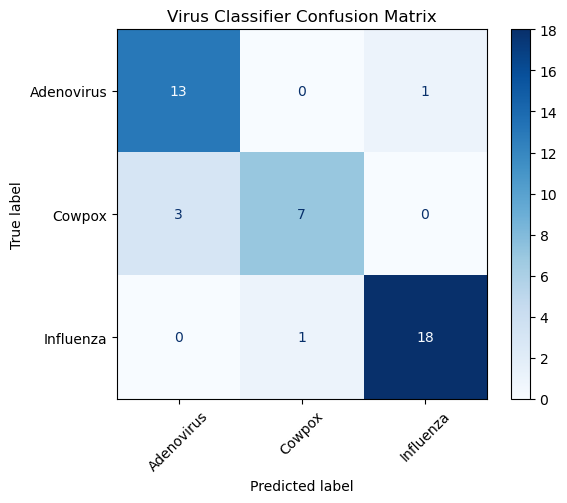

              precision    recall  f1-score   support

  Adenovirus       0.81      0.93      0.87        14
      Cowpox       0.88      0.70      0.78        10
   Influenza       0.95      0.95      0.95        19

    accuracy                           0.88        43
   macro avg       0.88      0.86      0.86        43
weighted avg       0.89      0.88      0.88        43



In [21]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=train_data.classes
)

disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Virus Classifier Confusion Matrix")
plt.show()

# Classification report
print(classification_report(
    all_labels,
    all_preds,
    target_names=train_data.classes
))

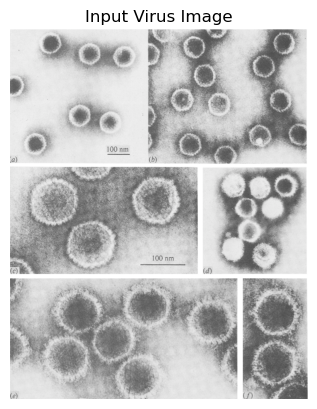

Predicted virus class: Influenza
Confidence: 0.6875686049461365

Generated hypothetical antibody-like sequence:
VH: QVQLQQSGAEVRKPGSSVKVSCKASGFTFRDSFDGSYKYYADSVKVSCKASGFTFRSNAWMAWINPNGGATYYYYYGMYVWGKGLEPRSVDKSKNTVHMELSSLRSEDTAVYYCARDRPHILTGGDIDYAVSG
VL: MTQSPLTLPVTLTISGLQPEDFASYYCQSYSTSPRLLIYDASNLQRGVPDRFSGSSSFLNWYQQKPGERATLGITGLQTGDEADYYCQQSRTDFATYYCMQTLQTPDFGQGTKLTVL


In [22]:
from PIL import Image
import matplotlib.pyplot as plt


input_image_path = r"C:\Users\dacnu\OneDrive\Desktop\AI stuff\test_virus_image.jpg"

# Show image
img = Image.open(input_image_path).convert("RGB")
plt.imshow(img)
plt.axis("off")
plt.title("Input Virus Image")
plt.show()

predicted_class, confidence = predict_virus(
    input_image_path,
    model,
    test_transform,
    train_data.classes
)

print("Predicted virus class:", predicted_class)
print("Confidence:", confidence)

if predicted_class in generators:
    generated_vh = generate_sequence(generators[predicted_class]["VH"], k=3)
    generated_vl = generate_sequence(generators[predicted_class]["VL"], k=3)

    print("\nGenerated hypothetical antibody-like sequence:")
    print("VH:", generated_vh)
    print("VL:", generated_vl)
else:
    print("No generator available for this virus class.")

Influenza is one of the closest viral classes to the herpes class (the test image being herpes simplex), so a ~69% confidence is expected for an accurate model. Additionally, the generated code cannot be confirmed as biologically functional in the current model; however, it can be compared to existing known herpes antibodies, and thus, an educated guess on whether this model is functional or not can be made.

In [23]:
herpes_raw = pd.read_excel("herpes_receptor_table_export.xlsx", sheet_name="Sheet1", header=[0, 1])

# Flatten multi-row headers
herpes_raw.columns = [
    f"{a}_{b}" if str(a) != "nan" else str(b)
    for a, b in herpes_raw.columns
]

herpes_clean = pd.DataFrame({
    "Virus": "Herpesvirus",
    "Source_ID": herpes_raw["Receptor_IEDB Receptor ID"],
    "VH_sequence": herpes_raw["Chain 1_V Domain Calculated"],
    "VL_sequence": herpes_raw["Chain 2_V Domain Calculated"],
    "VH_CDR3": herpes_raw["Chain 1_CDR3 Calculated"],
    "VL_CDR3": herpes_raw["Chain 2_CDR3 Calculated"]
})

herpes_clean = herpes_clean.dropna(subset=["VH_sequence", "VL_sequence"])

print("Herpes antibody rows:", herpes_clean.shape)
herpes_clean.head()

Herpes antibody rows: (72, 6)


,Virus,Source_ID,VH_sequence,VL_sequence,VH_CDR3,VL_CDR3
0,Herpesvirus,136,QVRLVESGGGVVQPGGSLRLSCEGSGFKFGDHGIHWVRQAPGEGLQ...,EIVLTQSPATLSLSPGERATLSCRASQSVGGYLTWYQHKPGQAPRL...,ARDGKCGGGRCYSGLLDY,QQRSMWPPVT
1,Herpesvirus,136,QVRLVESGGGVVQPGGSLRLSCEGSGFKFGDHGIHWVRQAPGEGLQ...,EIVLTQSPATLSLSPGERATLSCRASQSVGGYLTWYQHKPGQAPRL...,ARDGKCGGGRCYSGLLDY,QQRSMWPPVT
2,Herpesvirus,651,QVTLKQSGAEVKKPGSSVKVSCTASGGTLRTYGVSWVRQAPGQGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVTSSQLAWYQQKPGQAPR...,ARDLTTLTSYNWWDL,QQYGSSPT
3,Herpesvirus,764,EEQVLESGGGLVKPGGSLRLSCAASGFTFSPYSVFWVRQAPGKGLE...,DIVMTQSPLSLSVTPGEPASISCRSSQSLLHTNGYNYLDWYVQKPG...,ARDRSYYAFSSGSLSDYYYGLDV,MQALQIPRT
4,Herpesvirus,826,QVQLVQSGAEVRKPGASVKVSCKASGYSLKDHYMVWVRQAPGQGLE...,QSVLTQPPSVSAAPGQMVTISCSGSSSNIGKNYVSWYQQLPGAAPK...,ARDGAKTVSNSGLSLLYYHNRLDA,GTPDRSLSVV


In [24]:
from difflib import SequenceMatcher

def similarity(a, b):
    return SequenceMatcher(None, str(a), str(b)).ratio()

def compare_generated_to_dataset(generated_vh, generated_vl, reference_df, top_n=5):
    df_compare = reference_df.copy()

    df_compare["VH_similarity"] = df_compare["VH_sequence"].apply(
        lambda x: similarity(generated_vh, x)
    )

    df_compare["VL_similarity"] = df_compare["VL_sequence"].apply(
        lambda x: similarity(generated_vl, x)
    )

    df_compare["Average_similarity"] = (
        df_compare["VH_similarity"] + df_compare["VL_similarity"]
    ) / 2

    return df_compare.sort_values("Average_similarity", ascending=False).head(top_n)[
        [
            "Virus",
            "Source_ID",
            "VH_similarity",
            "VL_similarity",
            "Average_similarity",
            "VH_sequence",
            "VL_sequence"
        ]
    ]

In [25]:
compare_generated_to_dataset(
    generated_vh,
    generated_vl,
    herpes_clean,
    top_n=5
)

,Virus,Source_ID,VH_similarity,VL_similarity,Average_similarity,VH_sequence,VL_sequence
4,Herpesvirus,826,0.477273,0.495575,0.486424,QVQLVQSGAEVRKPGASVKVSCKASGYSLKDHYMVWVRQAPGQGLE...,QSVLTQPPSVSAAPGQMVTISCSGSSSNIGKNYVSWYQQLPGAAPK...
177,Herpesvirus,217304,0.477273,0.495575,0.486424,QVQLVQSGAEVRKPGASVKVSCKASGYSLKDHYMVWVRQAPGQGLE...,QSVLTQPPSVSAAPGQMVTISCSGSSSNIGKNYVSWYQQLPGAAPK...
2,Herpesvirus,651,0.486275,0.455357,0.470816,QVTLKQSGAEVKKPGSSVKVSCTASGGTLRTYGVSWVRQAPGQGLE...,EIVLTQSPGTLSLSPGERATLSCRASQSVTSSQLAWYQQKPGQAPR...
17,Herpesvirus,19642,0.440945,0.493506,0.467226,EVQLVQSGAEVKKPGESLKISCRESGDTFPAYWIAWVRQMPGKGLE...,DVVMTQSPLSLAVTLGQPAYISCRSSQSLGYSDGNTYLNWFQQRPG...
176,Herpesvirus,217078,0.441065,0.480349,0.460707,EEQVLESGGGLVKPGGSLRLSCAASGFTFSPYSVFWVRQAPGKGLE...,DIVMTQSPLSLSVTPGEPASISCRSSQSLLHTNGYNYLDWYVQKPG...


In [26]:
results = compare_generated_to_dataset(
    generated_vh,
    generated_vl,
    herpes_clean,
    top_n=5
)

print(results)

print("Best VH similarity:", results["VH_similarity"].max())
print("Best VL similarity:", results["VL_similarity"].max())
print("Best average similarity:", results["Average_similarity"].max())

           Virus  Source_ID  VH_similarity  VL_similarity  Average_similarity  \
4    Herpesvirus        826       0.477273       0.495575            0.486424   
177  Herpesvirus     217304       0.477273       0.495575            0.486424   
2    Herpesvirus        651       0.486275       0.455357            0.470816   
17   Herpesvirus      19642       0.440945       0.493506            0.467226   
176  Herpesvirus     217078       0.441065       0.480349            0.460707   

                                           VH_sequence  \
4    QVQLVQSGAEVRKPGASVKVSCKASGYSLKDHYMVWVRQAPGQGLE...   
177  QVQLVQSGAEVRKPGASVKVSCKASGYSLKDHYMVWVRQAPGQGLE...   
2    QVTLKQSGAEVKKPGSSVKVSCTASGGTLRTYGVSWVRQAPGQGLE...   
17   EVQLVQSGAEVKKPGESLKISCRESGDTFPAYWIAWVRQMPGKGLE...   
176  EEQVLESGGGLVKPGGSLRLSCAASGFTFSPYSVFWVRQAPGKGLE...   

                                           VL_sequence  
4    QSVLTQPPSVSAAPGQMVTISCSGSSSNIGKNYVSWYQQLPGAAPK...  
177  QSVLTQPPSVSAAPGQMVTISCSGSSSNIGKNYVSWYQQLPGAAP

With the given predictions being 48% on small sample sets and without training on herpes virus imaging the proof of concept can be considered a large success. There are still several ways to design this agent to be more accurate (training on amino acid structural data for example), but for its infancy, the expectation on accuracy was in the single digits.